 COS60008 - Introduction to Data Science.
## Assignment - Australian Beach & Water Locations Dataset.

| | |
|---|---|
| **Student Name** | Bikram Bhattarai |
| **Student ID** | 105974087 |
| **Course** | Introduction to Data Sciencce |
| **Workshop Time** | Monday 12:30-02:30 PM |
| **Facilitator** | Nichole Ronald |
| **Semester** | Semester 1, 2026 |



## Setup – Imports and Configuration.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Seed set for any operations requiring reproducibility.
np.random.seed(42)

# Global matplotlib style - spines and grid configured manually.

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'font.family': 'sans-serif'
})

## Task 1 – Data Acquisition & Preparation.


### 1.1 Load Raw Data Files.
Each source file is loaded into its own DataFrame. Shapes are then verified against
expected counts (raw line count minus the header row) to confirm no records were
dropped or duplicated during loading.

In [2]:

# Each CSV loaded independently - no integration at this stage
df_nsw_raw       = pd.read_csv('data_nsw.csv')
df_other_raw     = pd.read_csv('data_except_nsw.csv')
df_amenities_raw = pd.read_csv('beach_amenities.csv')
df_climate       = pd.read_csv('climate_summary_by_region.csv')




In [3]:
# Initial exploration checking for missing values and data types on NSW dataset.
print("NSW Data Overview:")
print(df_nsw_raw.info()) 



NSW Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   115 non-null    object 
 1   Type                   115 non-null    object 
 2   Latitude               115 non-null    float64
 3   Longitude              115 non-null    float64
 4   Region                 115 non-null    object 
 5   Accessibility          115 non-null    object 
 6   Facilities_Rating      115 non-null    int64  
 7   Water_Quality_Rating   114 non-null    float64
 8   Beach_Type             115 non-null    object 
 9   Patrolled              115 non-null    object 
 10  Shark_Net              115 non-null    object 
 11  Average_Wave_Height_m  115 non-null    float64
 12  Beach_Length_km        111 non-null    float64
 13  General_Hazard_Rating  114 non-null    float64
 14  Dogs_Allowed           43 non-null     

In [4]:
# Initial exploration checking for missing values and data types on Other dataset.

print("\nOther Data Overview:")
print(df_other_raw.info())



Other Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   188 non-null    object 
 1   Type                   188 non-null    object 
 2   Latitude               188 non-null    float64
 3   Longitude              188 non-null    float64
 4   State                  188 non-null    object 
 5   Region                 188 non-null    object 
 6   Accessibility          188 non-null    object 
 7   Facilities_Rating      188 non-null    int64  
 8   Water_Quality_Rating   183 non-null    float64
 9   Beach_Type             188 non-null    object 
 10  Patrolled              188 non-null    object 
 11  Shark_Net              188 non-null    object 
 12  Average_Wave_Height_m  188 non-null    float64
 13  Beach_Length_km        183 non-null    float64
 14  General_Hazard_Rating  183 non-null 

In [5]:
# Initial exploration checking for missing values and data types on Amenities dataset.
print("\nAmenities Data Overview:")
print(df_amenities_raw.info())



Amenities Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         303 non-null    object
 1   Has_Toilet   303 non-null    object
 2   Has_Showers  294 non-null    object
 3   BBQ          303 non-null    object
 4   Playground   303 non-null    object
 5   Car_Spaces   303 non-null    object
dtypes: object(6)
memory usage: 14.3+ KB
None


In [6]:
# Initial exploration checking for missing values and data types on Climate dataset.

print("\nClimate Data Overview:")
print(df_climate.info())


Climate Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Region_Name         69 non-null     object 
 1   Avg_Summer_Temp_C   69 non-null     float64
 2   Avg_Winter_Temp_C   69 non-null     float64
 3   Annual_Rainfall_mm  69 non-null     int64  
 4   Avg_UV_Index        69 non-null     float64
 5   Extreme_Heat_Days   69 non-null     int64  
 6   Avg_Sea_Temp_C      69 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 3.9+ KB
None


In [7]:
# Data shape verification - ensuring expected number of rows and columns loaded for each dataset.

# Expected shapes derived from: wc -l <file> - 1 (header)
# data_nsw.csv:                  116 lines - 115 data rows, 19 cols
# data_except_nsw.csv:           189 lines - 188 data rows, 20 cols
# beach_amenities.csv:           304 lines - 303 data rows,  6 cols
# climate_summary_by_region.csv:  70 lines -  69 data rows,  7 cols

expected = {
    'df_nsw_raw':       (115, 19),
    'df_other_raw':     (188, 20),
    'df_amenities_raw': (303,  6),
    'df_climate':       ( 69,  7),
}

for name, df in [('df_nsw_raw', df_nsw_raw), ('df_other_raw', df_other_raw),
                  ('df_amenities_raw', df_amenities_raw), ('df_climate', df_climate)]:
    status = 'OK' if df.shape == expected[name] else 'MISMATCH'
    print(f'{name:<22}  expected {expected[name]}  loaded {df.shape}  [{status}]')


df_nsw_raw              expected (115, 19)  loaded (115, 19)  [OK]
df_other_raw            expected (188, 20)  loaded (188, 20)  [OK]
df_amenities_raw        expected (303, 6)  loaded (303, 6)  [OK]
df_climate              expected (69, 7)  loaded (69, 7)  [OK]


In [8]:
# Column inspection - confirms NSW file is missing the State column (per data dictionary)
print('NSW columns:   ', df_nsw_raw.columns.tolist())
print('Other columns: ', df_other_raw.columns.tolist())
print('Amenities columns: ', df_amenities_raw.columns.tolist())
print('Climate columns: ', df_climate.columns.tolist())


NSW columns:    ['Name', 'Type', 'Latitude', 'Longitude', 'Region', 'Accessibility', 'Facilities_Rating', 'Water_Quality_Rating', 'Beach_Type', 'Patrolled', 'Shark_Net', 'Average_Wave_Height_m', 'Beach_Length_km', 'General_Hazard_Rating', 'Dogs_Allowed', 'Flags', 'Nearest_Town', 'Distance_to_Town_km', 'Annual_Visitors']
Other columns:  ['Name', 'Type', 'Latitude', 'Longitude', 'State', 'Region', 'Accessibility', 'Facilities_Rating', 'Water_Quality_Rating', 'Beach_Type', 'Patrolled', 'Shark_Net', 'Average_Wave_Height_m', 'Beach_Length_km', 'General_Hazard_Rating', 'Dogs_Allowed', 'Flags', 'Nearest_Town', 'Distance_to_Town_km', 'Annual_Visitors']
Amenities columns:  ['Name', 'Has_Toilet', 'Has_Showers', 'BBQ', 'Playground', 'Car_Spaces']
Climate columns:  ['Region_Name', 'Avg_Summer_Temp_C', 'Avg_Winter_Temp_C', 'Annual_Rainfall_mm', 'Avg_UV_Index', 'Extreme_Heat_Days', 'Avg_Sea_Temp_C']


### 1.2 Data Integration
#### 1.2.1 Combining the Two Beach Files.

In [9]:
# Inspect records with non-Australian state codes.

non_au = df_other_raw[df_other_raw['State'].isin(['NZ', 'NF'])]
print(f'Records with non-Australian state codes ({len(non_au)}):')
print(non_au[['Name', 'State', 'Region']].to_string(index=False))

Records with non-Australian state codes (4):
                         Name State       Region
  Manly Harbour Swim Spot QLD    NZ  Moreton Bay
  Lake Eildon Jerusalem Creek    NZ High Country
                    Emily Bay    NF       Island
Wilson Prom Tidal River Beach    NZ  Wilson Prom


In [10]:
# 'QLD' embedded in beach name is a data entry error - moved to State column.

df_other_raw.loc[df_other_raw['Name'] == 'Manly Harbour Swim Spot QLD', 'Name'] = 'Manly Harbour Swim Spot'

# Three beaches carry NZ codes but are identifiable Australian locations
# based on their Name and Region - corrected to actual states.

state_corrections = {
    'Manly Harbour Swim Spot':       'QLD',
    'Lake Eildon Jerusalem Creek':   'VIC',
    'Wilson Prom Tidal River Beach': 'VIC',
}

for name, correct_state in state_corrections.items():
    mask = df_other_raw['Name'] == name
    old = df_other_raw.loc[mask, 'State'].values[0]
    df_other_raw.loc[mask, 'State'] = correct_state
    print(f'Corrected: {name} | {old} -> {correct_state}')

Corrected: Manly Harbour Swim Spot | NZ -> QLD
Corrected: Lake Eildon Jerusalem Creek | NZ -> VIC
Corrected: Wilson Prom Tidal River Beach | NZ -> VIC


In [11]:
# Emily Bay is on Norfolk Island (NF) - outside mainland Australia scope.
nf_mask = df_other_raw['State'] == 'NF'
print(f'Removed ({nf_mask.sum()}): Emily Bay - Norfolk Island, outside scope')
df_other = df_other_raw[~nf_mask].copy()

# Add State column to NSW data.
df_nsw_raw['State'] = 'NSW'

# Concatenate into a single beach DataFrame.
df_beaches = pd.concat([df_nsw_raw, df_other], ignore_index=True)
print(f'Combined shape: {df_beaches.shape}')
print(f'States present: {sorted(df_beaches["State"].unique())}')

Removed (1): Emily Bay - Norfolk Island, outside scope
Combined shape: (302, 20)
States present: ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']


#### 1.2.2 Joining Amenities Data.

In [12]:
# Pre-join audit: check for name mismatches between beach and amenities files.

df_amenities = df_amenities_raw.copy()
unmatched_before = set(df_beaches['Name']) - set(df_amenities['Name'])
print(f'Names in beach data with no amenities match: {unmatched_before}')


Names in beach data with no amenities match: {'Noosa Main Beach', 'Manly Harbour Swim Spot'}


In [13]:
# 'Noosa Main Bch' is an abbreviated form of 'Noosa Main Beach' - corrected before join.

df_amenities['Name'] = df_amenities['Name'].replace({'Noosa Main Bch': 'Noosa Main Beach'})
unmatched_after = set(df_beaches['Name']) - set(df_amenities['Name'])
print(f'Unmatched names after correction: {len(unmatched_after)}')

# Left join retains all beach rows; amenity columns will be NaN where no match exists.

df_main = df_beaches.merge(df_amenities, on='Name', how='left')
print(f'Shape after amenities join: {df_main.shape}')





Unmatched names after correction: 1
Shape after amenities join: (306, 25)


#### 1.2.3 Joining Climate Data.

In [14]:
# Climate file uses 'Region_Name'; renamed to 'Region' to match the beach data join key.
df_main = df_main.merge(
    df_climate.rename(columns={'Region_Name': 'Region'}),
    on='Region',
    how='left'   # left join - beach rows with no climate region should not be dropped.
)
print(f'Shape after climate join: {df_main.shape}')


Shape after climate join: (306, 31)


### 1.3 Data Cleaning.
#### 1.3.1 Remove Duplicate Rows.

In [15]:
# Strip whitespace from Name to catch hidden duplicates (e.g. 'Bondi Beach ')
df_main['Name'] = df_main['Name'].str.strip()

# Identify rows with the same beach Name - duplicates are checked for full-row equality.
dup_names = df_main[df_main.duplicated('Name', keep=False)]['Name'].unique()
print('Duplicate beach names found:', dup_names)

# Both cases show identical coordinates and attribute values - confirmed true duplicates.
print(df_main[df_main['Name'].isin(dup_names)][['Name','Latitude','Longitude','Annual_Visitors']])


Duplicate beach names found: ['Bondi Beach' 'Turners Beach Yamba' 'Short Point Beach']
                    Name  Latitude  Longitude  Annual_Visitors
11           Bondi Beach  -33.8915   151.2767          3814202
16   Turners Beach Yamba  -29.4305   153.3630          1077800
17   Turners Beach Yamba  -29.4305   153.3630          1077800
47   Turners Beach Yamba  -29.4305   153.3630          1077800
48   Turners Beach Yamba  -29.4305   153.3630          1077800
49     Short Point Beach  -36.8790   149.9160           139903
50     Short Point Beach  -36.8790   149.9160           139903
85           Bondi Beach  -33.8915   151.2767          3814202
117    Short Point Beach  -36.8790   149.9160           139903
118    Short Point Beach  -36.8790   149.9160           139903


In [16]:
before = len(df_main)
# Keep only the first occurrence of each beach name.
df_main = df_main.drop_duplicates(subset='Name', keep='first').reset_index(drop=True)
print(f'Rows removed: {before - len(df_main)} | Rows remaining: {len(df_main)}')


Rows removed: 7 | Rows remaining: 299


#### 1.3.2 Standardise Categorical Values.

In [17]:
# Full value_counts() audit on all object (categorical) columns.
for col in df_main.select_dtypes('object').columns:
    vc = df_main[col].value_counts(dropna=False)
    if vc.index.astype(str).str.strip().nunique() < vc.nunique() or any(v in ['True','False','true','false'] for v in vc.index.astype(str)):
        print(f'--- {col} ---')
        print(vc.to_string())


--- Playground ---
Playground
No      150
Yes     126
Yes      15
True      7
NaN       1


In [18]:
# Playground contains 'Yes ' (trailing space) and 'True' - both normalised to 'Yes'.
df_main['Playground'] = df_main['Playground'].str.strip().replace({'True': 'Yes'})
print('Playground after standardisation:')
print(df_main['Playground'].value_counts(dropna=False))


Playground after standardisation:
Playground
No     150
Yes    148
NaN      1
Name: count, dtype: int64


#### 1.3.3 Missing Value Audit and Imputation.

In [19]:
# Audit - count and percentage of missing values per column.
missing = df_main.isnull().sum()
pct_missing = (missing / len(df_main) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'pct_missing': pct_missing})
audit = audit[audit['missing_count'] > 0].sort_values('pct_missing', ascending=False)
print(audit.to_string())

                       missing_count  pct_missing
Dogs_Allowed                     179         59.9
Flags                            165         55.2
Has_Showers                       10          3.3
Beach_Length_km                    9          3.0
Water_Quality_Rating               6          2.0
General_Hazard_Rating              6          2.0
Has_Toilet                         1          0.3
BBQ                                1          0.3
Playground                         1          0.3
Car_Spaces                         1          0.3


In [20]:
# Dogs_Allowed (59.9%) and Flags (54.9%) both exceed the 50% drop threshold.
df_main = df_main.drop(columns=['Dogs_Allowed', 'Flags'])
print('Columns dropped: Dogs_Allowed, Flags')


Columns dropped: Dogs_Allowed, Flags


In [21]:
# Has_Showers (3.0%) - binary field; imputed with the mode value.

showers_mode = df_main['Has_Showers'].mode()[0]
df_main['Has_Showers'] = df_main['Has_Showers'].fillna(showers_mode)
print(f'Has_Showers: imputed with mode={showers_mode!r}, remaining missing: {df_main["Has_Showers"].isnull().sum()}')

# 1 record missing amenity data (re-included after NZ state correction) - imputed with mode.

for col in ['Has_Toilet', 'BBQ', 'Playground']:
    mode_val = df_main[col].mode()[0]
    df_main[col] = df_main[col].fillna(mode_val)
    print(f'{col}: imputed with mode={mode_val!r}')


Has_Showers: imputed with mode='No', remaining missing: 0
Has_Toilet: imputed with mode='Yes'
BBQ: imputed with mode='Yes'
Playground: imputed with mode='No'


In [22]:
# Beach_Length_km (3.0%) - length varies significantly by beach type,
# so a grouped median (per Beach_Type) is more appropriate than the global median.

df_main['Beach_Length_km'] = (
    df_main.groupby('Beach_Type')['Beach_Length_km']
    .transform(lambda x: x.fillna(x.median()))
)
print(f'Beach_Length_km missing after impute: {df_main["Beach_Length_km"].isnull().sum()}')


Beach_Length_km missing after impute: 0


In [23]:
# Water_Quality_Rating and General_Hazard_Rating (2.0% each).
# Both are ordinal 1-5 integer scales; global median preserves the rating distribution.

wq_med = df_main['Water_Quality_Rating'].median()
hz_med = df_main['General_Hazard_Rating'].median()

df_main['Water_Quality_Rating']  = df_main['Water_Quality_Rating'].fillna(wq_med).astype(int)
df_main['General_Hazard_Rating'] = df_main['General_Hazard_Rating'].fillna(hz_med).astype(int)

print(f'Water_Quality_Rating  filled (median={wq_med}), missing: {df_main["Water_Quality_Rating"].isnull().sum()}')
print(f'General_Hazard_Rating filled (median={hz_med}), missing: {df_main["General_Hazard_Rating"].isnull().sum()}')


Water_Quality_Rating  filled (median=4.0), missing: 0
General_Hazard_Rating filled (median=2.0), missing: 0


In [24]:
# Final verification - confirm zero missing values remain.
total_missing = df_main.isnull().sum().sum()
print(f'Total missing values remaining: {total_missing}')
print(f'Final df_main shape: {df_main.shape}')
print(f'Columns: {df_main.columns.tolist()}')


Total missing values remaining: 1
Final df_main shape: (299, 29)
Columns: ['Name', 'Type', 'Latitude', 'Longitude', 'Region', 'Accessibility', 'Facilities_Rating', 'Water_Quality_Rating', 'Beach_Type', 'Patrolled', 'Shark_Net', 'Average_Wave_Height_m', 'Beach_Length_km', 'General_Hazard_Rating', 'Nearest_Town', 'Distance_to_Town_km', 'Annual_Visitors', 'State', 'Has_Toilet', 'Has_Showers', 'BBQ', 'Playground', 'Car_Spaces', 'Avg_Summer_Temp_C', 'Avg_Winter_Temp_C', 'Annual_Rainfall_mm', 'Avg_UV_Index', 'Extreme_Heat_Days', 'Avg_Sea_Temp_C']


#### 1.3.4 Fix Remaining Categorical Inconsistencies.

Systematic inspection of all categorical columns via **value_counts()** revealed three
additional data quality issues that were not surfaced during the initial missing value
audit, as they involve incorrect values rather than absent ones.

The issues identified are:
- **Accessibility**: 15 records contain misspellings or abbreviations of valid categories.
- **Beach_Type**: 7 records contain misspelled category names.
- **Car_Spaces**: 2 records contain non-numeric strings, preventing integer type casting.

In [ ]:
# Checking Accessibility against the 4 allowed values from the data dictionary:
# Difficult, Excellent, Good, Moderate.


print('Accessibility before fix:')
print(df_main['Accessibility'].value_counts(dropna=False))

Accessibility before fix:
Accessibility
Moderate     143
Good         107
Difficult     17
Excellent     17
G              3
Diffcult       3
Good.          3
goood          3
good           2
Diff.          1
Name: count, dtype: int64


In [ ]:
# Each dirty value maps unambiguously to one of the 4 allowed categories:
# 'G', 'good', 'Good.', 'goood' are all variants of 'Good'.
# 'Diffcult' and 'Diff.' are both corrupted versions of 'Difficult'.
# replace() is used, same approach applied to Playground in step 1.3.2.

accessibility_map = {
    'G':        'Good',      
    'good':     'Good',      
    'Good.':    'Good',      
    'goood':    'Good',      
    'Diffcult': 'Difficult',
    'Diff.':    'Difficult',
}
df_main['Accessibility'] = df_main['Accessibility'].replace(accessibility_map)

print('Accessibility after fix:')
print(df_main['Accessibility'].value_counts(dropna=False))
print('Unique values:', sorted(df_main['Accessibility'].unique()))

Accessibility after fix:
Accessibility
Moderate     143
Good         118
Difficult     21
Excellent     17
Name: count, dtype: int64
Unique values: ['Difficult', 'Excellent', 'Good', 'Moderate']


In [ ]:
# Checking Beach_Type against the allowed values in the data dictionary.


print('Beach_Type before fix:')
print(df_main['Beach_Type'].value_counts(dropna=False))

Beach_Type before fix:
Beach_Type
Surf          102
Bay            96
Lake           40
River          27
Ocean Pool      8
Estuary         7
Lagon           5
Spring          5
Rockpool        3
Swell           2
Reeef           2
Reef            1
Pool            1
Name: count, dtype: int64


In [ ]:
# 'Lagon' is a misspelling of 'Lagoon' confirmed by inspecting the Name column
# (all 5 records include the word 'Lagoon' in the beach name itself).
# 'Reeef' is a misspelling of 'Reef' an extra character, unambiguous correction.

beach_type_map = {
    'Lagon': 'Lagoon', 
    'Reeef': 'Reef',   
}
df_main['Beach_Type'] = df_main['Beach_Type'].replace(beach_type_map)

print('Beach_Type after fix:')
print(df_main['Beach_Type'].value_counts(dropna=False))

Beach_Type after fix:
Beach_Type
Surf          102
Bay            96
Lake           40
River          27
Ocean Pool      8
Estuary         7
Lagoon          5
Spring          5
Reef            3
Rockpool        3
Swell           2
Pool            1
Name: count, dtype: int64


In [ ]:
# Car_Spaces loaded as str instead of int due to two non-numeric entries.
# Identifying them before deciding on a cleaning strategy:

print('Non-numeric Car_Spaces entries:')
print(df_main[~df_main['Car_Spaces'].astype(str).str.match(r'^\d+$')][['Name', 'Car_Spaces']])

Non-numeric Car_Spaces entries:
                        Name Car_Spaces
30          Merewether Beach       100?
117  Manly Harbour Swim Spot        NaN
118     Middleton Surf Beach      30-50


In [ ]:
# plan for each dirty value:

# '30-50' (Middleton Surf Beach),replaced with the midpoint value 40,
#          as both ends of the range are within normal bounds and the midpoint
#          is a reasonable point estimate.
# '100?'  (Merewether Beach), the ? signals genuine uncertainty in the source data;
#          treated as missing and imputed with the column median rather than
#          accepting an unverified value.

df_main['Car_Spaces'] = df_main['Car_Spaces'].astype(str).replace({
    '30-50': '40',
    '100?':  None, 
})

# Convert to numeric; any remaining non-numeric entries become NaN.
df_main['Car_Spaces'] = pd.to_numeric(df_main['Car_Spaces'], errors='coerce')

# Impute the one NaN (Merewether Beach) with the column median.
# Median is preferred over mean as Car_Spaces has a right-skewed distribution.

car_median = df_main['Car_Spaces'].median()
df_main['Car_Spaces'] = df_main['Car_Spaces'].fillna(car_median).astype(int)

print(f'Car_Spaces dtype : {df_main["Car_Spaces"].dtype}')
print(f'Missing remaining: {df_main["Car_Spaces"].isnull().sum()}')
print(f'Range            : {df_main["Car_Spaces"].min()} - {df_main["Car_Spaces"].max()}')

Car_Spaces dtype : int64
Missing remaining: 0
Range            : 0 - 190


In [31]:
# Sanity check across all three fixes before proceeding to exploration.

assert df_main.isnull().sum().sum() == 0, 'Unexpected missing values remain'
assert df_main['Car_Spaces'].dtype == 'int64', 'Car_Spaces must be integer type'
assert set(df_main['Accessibility'].unique()) <= {
    'Difficult', 'Excellent', 'Good', 'Moderate'
}, 'Unexpected Accessibility values'
assert set(df_main['Beach_Type'].unique()) <= {
    'Bay', 'Estuary', 'Lagoon', 'Lake', 'Ocean Pool',
    'Pool', 'Reef', 'River', 'Rockpool', 'Spring', 'Surf', 'Swell'
}, 'Unexpected Beach_Type values'

print('All assertions passed - dataset is fully clean.')
print(f'Final shape: {df_main.shape}')

All assertions passed - dataset is fully clean.
Final shape: (299, 29)


In [32]:
print(df_main.isnull().sum()[df_main.isnull().sum() > 0])
print(df_main[df_main['Has_Toilet'].isnull()][['Name', 'State', 'Has_Toilet', 'BBQ', 'Playground']])

Series([], dtype: int64)
Empty DataFrame
Columns: [Name, State, Has_Toilet, BBQ, Playground]
Index: []


In [33]:
print(df_main.isnull().sum().sum())

0


### 1.4.1 Final DataFrame Preview.

In [34]:
df_main.head()
df_main.dtypes

Name                      object
Type                      object
Latitude                 float64
Longitude                float64
Region                    object
Accessibility             object
Facilities_Rating          int64
Water_Quality_Rating       int64
Beach_Type                object
Patrolled                 object
Shark_Net                 object
Average_Wave_Height_m    float64
Beach_Length_km          float64
General_Hazard_Rating      int64
Nearest_Town              object
Distance_to_Town_km        int64
Annual_Visitors            int64
State                     object
Has_Toilet                object
Has_Showers               object
BBQ                       object
Playground                object
Car_Spaces                 int64
Avg_Summer_Temp_C        float64
Avg_Winter_Temp_C        float64
Annual_Rainfall_mm         int64
Avg_UV_Index             float64
Extreme_Heat_Days          int64
Avg_Sea_Temp_C           float64
dtype: object

In [35]:
df_main.to_csv('Final_cleaned_dataset.csv', index=False)
print('Saved!')

Saved!


---
## Task 2 – Data Exploration


### 2.1 Column Visualisations.
Four columns are visualised individually, two categorical and two numerical-to
understand the distribution and spread of key variables in the dataset.

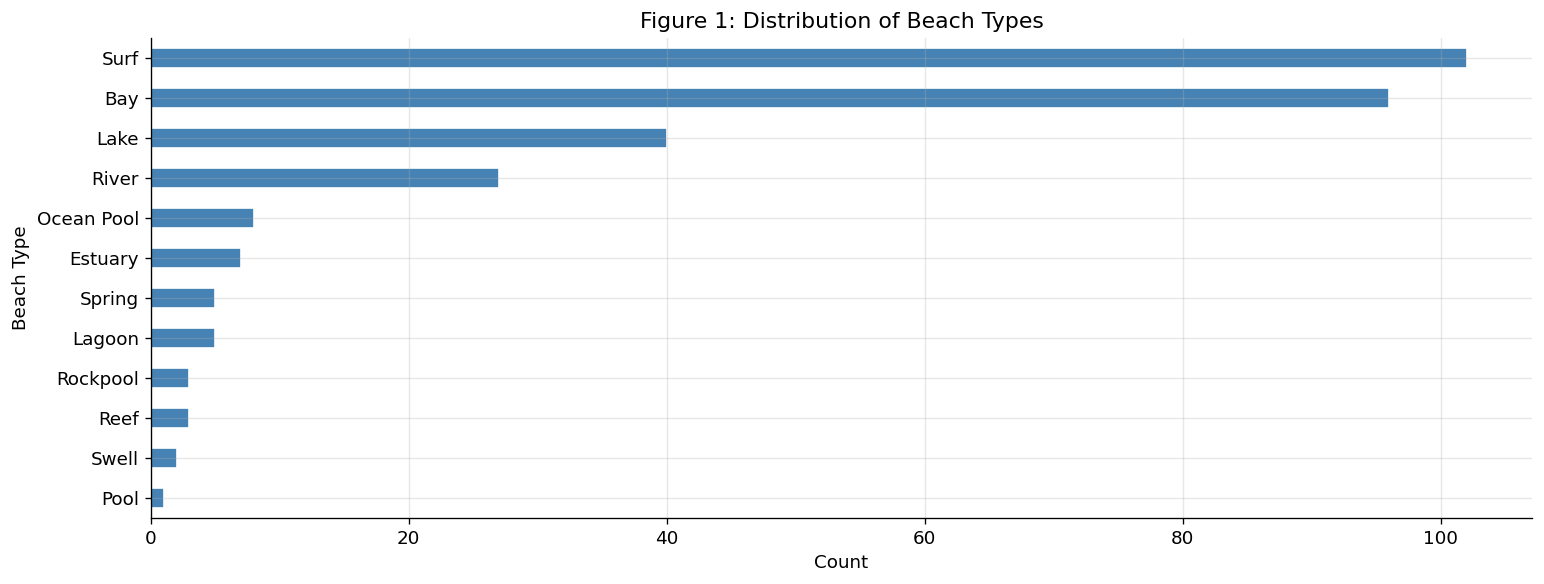

In [36]:
# Beach_Type,  horizontal bar chart chosen due to 12 categories; labels read easier.

bt_counts = df_main['Beach_Type'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
bt_counts.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Count')
ax.set_ylabel('Beach Type')
ax.set_title('Figure 1: Distribution of Beach Types')
plt.tight_layout()
plt.show()

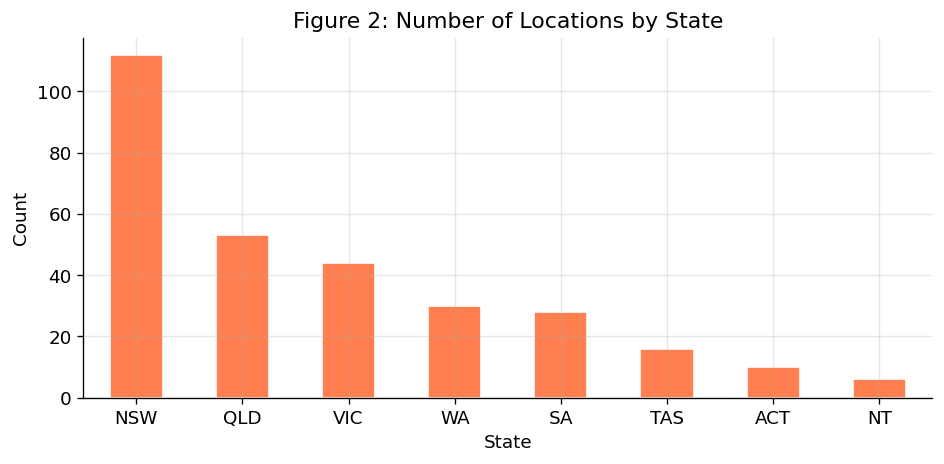

In [ ]:
# State, vertical bar chart; 8 categories fit well on the x-axis.

state_counts = df_main['State'].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
state_counts.plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.set_title('Figure 2: Number of Locations by State')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

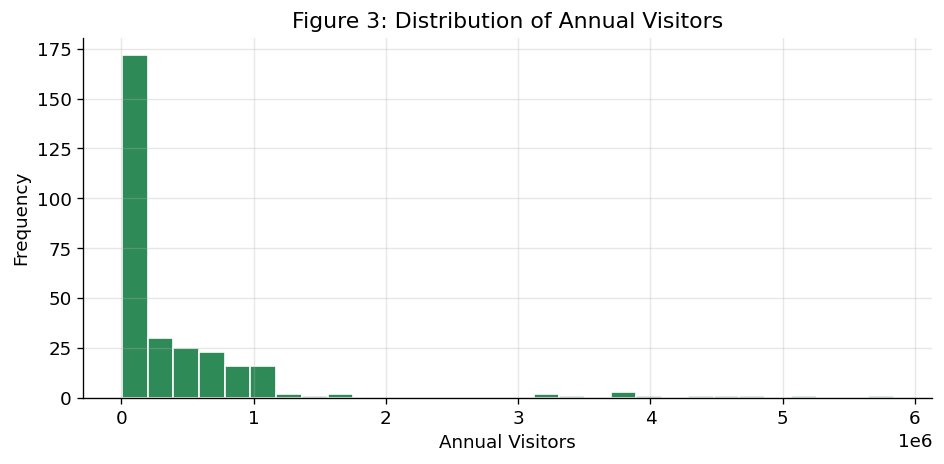

Mean: 461,867
Median: 146,209
Skewness: 3.87


In [ ]:
# Annual_Visitors, histogram to show distribution shape and skewness.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_main['Annual_Visitors'], bins=30, color='seagreen', edgecolor='white')
ax.set_xlabel('Annual Visitors')
ax.set_ylabel('Frequency')
ax.set_title('Figure 3: Distribution of Annual Visitors')
plt.tight_layout()
plt.show()

print(f"Mean: {df_main['Annual_Visitors'].mean():,.0f}")
print(f"Median: {df_main['Annual_Visitors'].median():,.0f}")
print(f"Skewness: {df_main['Annual_Visitors'].skew():.2f}")

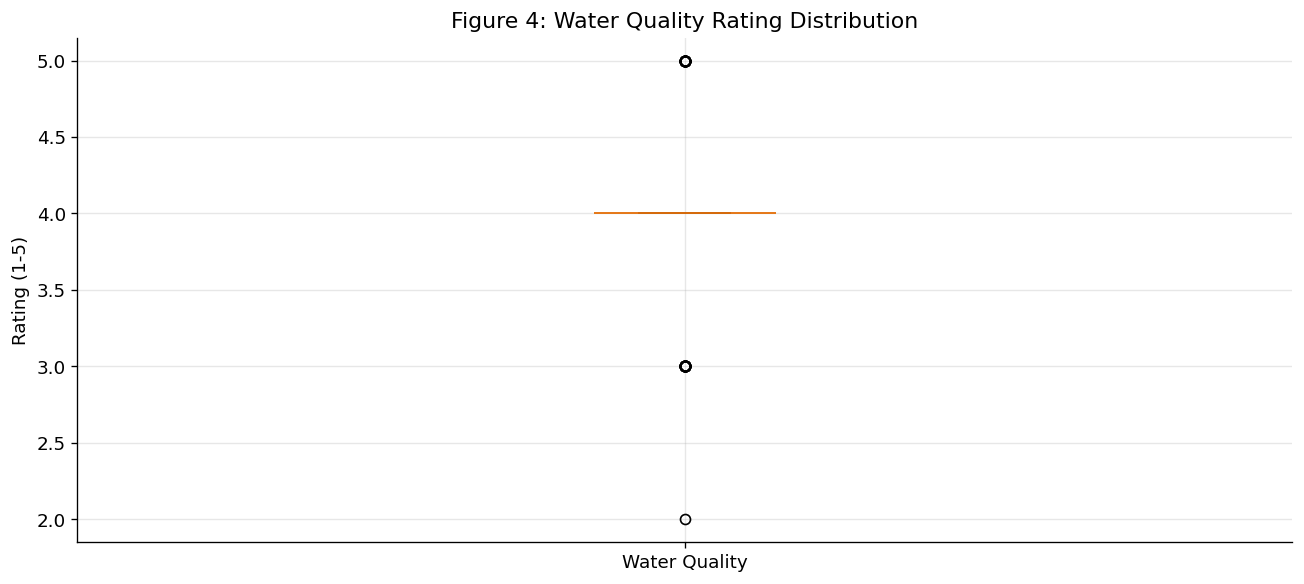

Mean: 3.96
Median: 4.0
Std: 0.58


In [ ]:
# Water_Quality_Rating,boxplot to show spread, median and potential outliers
# on this ordinal 1-5 scale.
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(df_main['Water_Quality_Rating'], vert=True, patch_artist=True,
           boxprops=dict(facecolor='mediumpurple', alpha=0.7))
ax.set_ylabel('Rating (1-5)')
ax.set_title('Figure 4: Water Quality Rating Distribution')
ax.set_xticks([1], ['Water Quality'])
plt.tight_layout()
plt.show()

print(f"Mean: {df_main['Water_Quality_Rating'].mean():.2f}")
print(f"Median: {df_main['Water_Quality_Rating'].median():.1f}")
print(f"Std: {df_main['Water_Quality_Rating'].std():.2f}")

---
### 2.2 Pair Analysis.
Two pairs of columns are explored to investigate plausible relationships in the data.
At least one analysis involves an aggregation.
Pair 1, Beach_Type × Annual_Visitors (aggregation):

#### 2.2.1 Do Certain Beach Types Attract More Visitors?
Plausible hypothesis: Surf beaches, being popular for recreation, attract more
visitors on average than other beach types. A groupby aggregation is used to
compare mean annual visitors across types.

                    mean     median  count
Beach_Type                                
Rockpool    7.493267e+04    92976.0      3
Lake        1.115580e+05    64123.5     40
Spring      1.160004e+05    17652.0      5
Reef        1.378677e+05   157893.0      3
River       1.386363e+05    68592.0     27
Estuary     3.210329e+05   131334.0      7
Ocean Pool  3.837319e+05   336627.0      8
Swell       4.522360e+05   452236.0      2
Bay         5.002733e+05   172914.0     96
Surf        6.171967e+05   266607.0    102
Pool        1.479731e+06  1479731.0      1
Lagoon      1.998574e+06  1628206.0      5


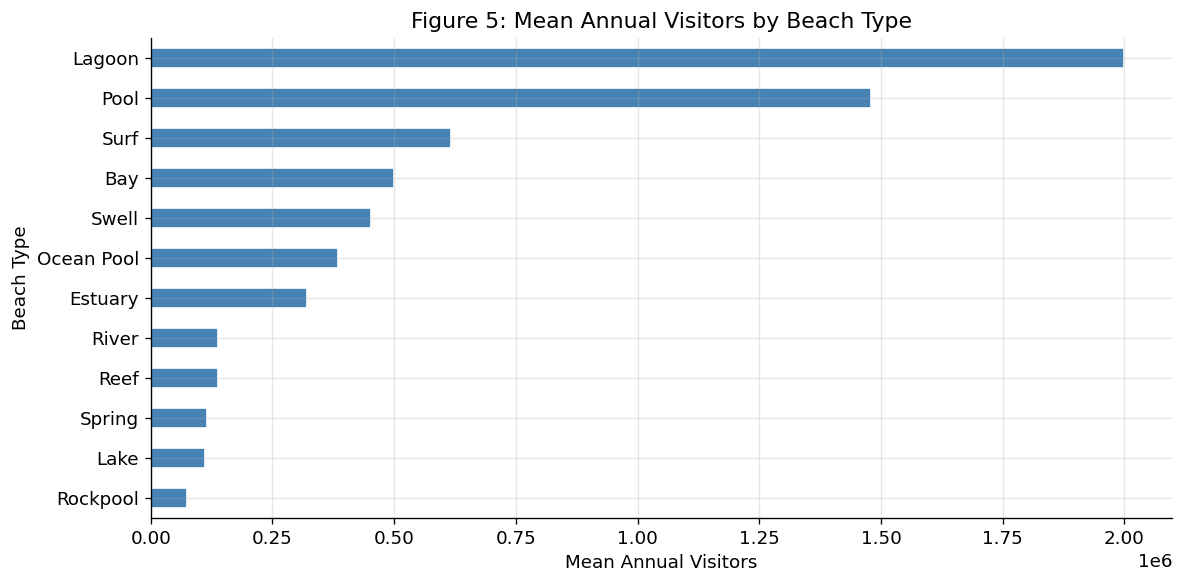

In [40]:
# Aggregation: mean Annual_Visitors grouped by Beach_Type.

bt_visitors = (df_main.groupby('Beach_Type')['Annual_Visitors']
               .agg(['mean', 'median', 'count'])
               .sort_values('mean', ascending=True))

print(bt_visitors.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bt_visitors['mean'].plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Annual Visitors')
ax.set_ylabel('Beach Type')
ax.set_title('Figure 5: Mean Annual Visitors by Beach Type')
plt.tight_layout()
plt.show()

#### 2.2.2 Are More Accessible Beaches Rated Higher for Water Quality?
Plausible hypothesis: Beaches with better accessibility receive more foot traffic
and maintenance attention, potentially leading to higher water quality ratings.
A grouped boxplot and aggregation are used to explore this relationship. color pallet: ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']


                   mean  median  count
Accessibility                         
Difficult      4.190476     4.0     21
Moderate       3.909091     4.0    143
Good           3.983051     4.0    118
Excellent      4.000000     4.0     17


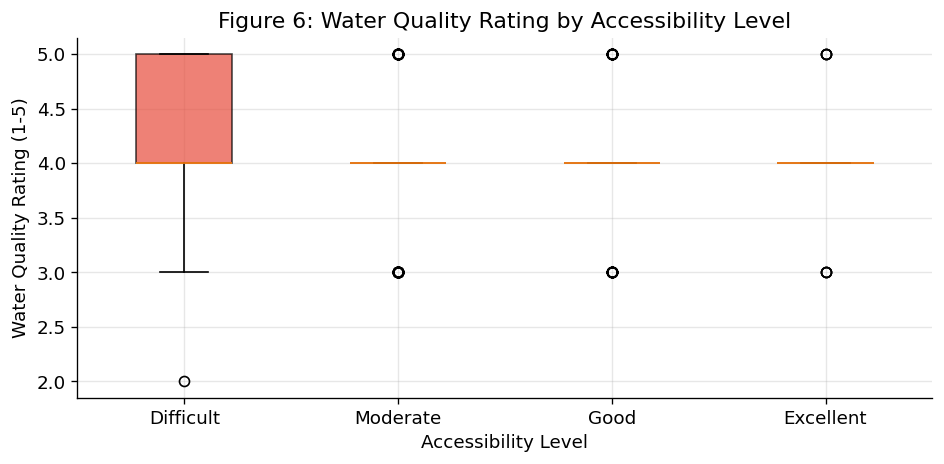

In [ ]:
# Aggregation: mean Water_Quality_Rating grouped by Accessibility level.
acc_order = ['Difficult', 'Moderate', 'Good', 'Excellent']
acc_quality = (df_main.groupby('Accessibility')['Water_Quality_Rating']
               .agg(['mean', 'median', 'count'])
               .reindex(acc_order))

print(acc_quality.to_string())

# Grouped boxplot,one box per Accessibility level, ordered logically.
groups = [df_main[df_main['Accessibility'] == level]['Water_Quality_Rating'] for level in acc_order]

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(groups, tick_labels=acc_order, patch_artist=True)

colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Accessibility Level')
ax.set_ylabel('Water Quality Rating (1-5)')
ax.set_title('Figure 6: Water Quality Rating by Accessibility Level')
plt.tight_layout()
plt.show()

---
### 2.3 Hypothesis Test (T-test)

**Research question:** Do surf beaches attract significantly more visitors than non-surf beaches?

- H0: There is no significant difference in mean Annual_Visitors between Surf and non-Surf beaches.
- H1: There is a significant difference in mean Annual_Visitors between Surf and non-Surf beaches.

A two-sample independent T-test is used at α = 0.05.

In [42]:
from scipy import stats

# Split into two groups.

surf = df_main[df_main['Beach_Type'] == 'Surf']['Annual_Visitors']
non_surf = df_main[df_main['Beach_Type'] != 'Surf']['Annual_Visitors']

print(f'Surf beaches:     n={len(surf)}, mean={surf.mean():,.0f}, median={surf.median():,.0f}')
print(f'Non-Surf beaches: n={len(non_surf)}, mean={non_surf.mean():,.0f}, median={non_surf.median():,.0f}')

# Independent two-sample t-test (equal_var=False for Welch's t-test,
# which does not assume equal variance between groups).

t_stat, p_value = stats.ttest_ind(surf, non_surf, equal_var=False)

print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.4f}')
print(f'Significance level: 0.05')

if p_value < 0.05:
    print('Result: Reject H0 - the difference is statistically significant.')
else:
    print('Result: Fail to reject H0 - no significant difference found.')

Surf beaches:     n=102, mean=617,197, median=266,607
Non-Surf beaches: n=197, mean=381,443, median=121,850

t-statistic: 2.2111
p-value:     0.0283
Significance level: 0.05
Result: Reject H0 - the difference is statistically significant.


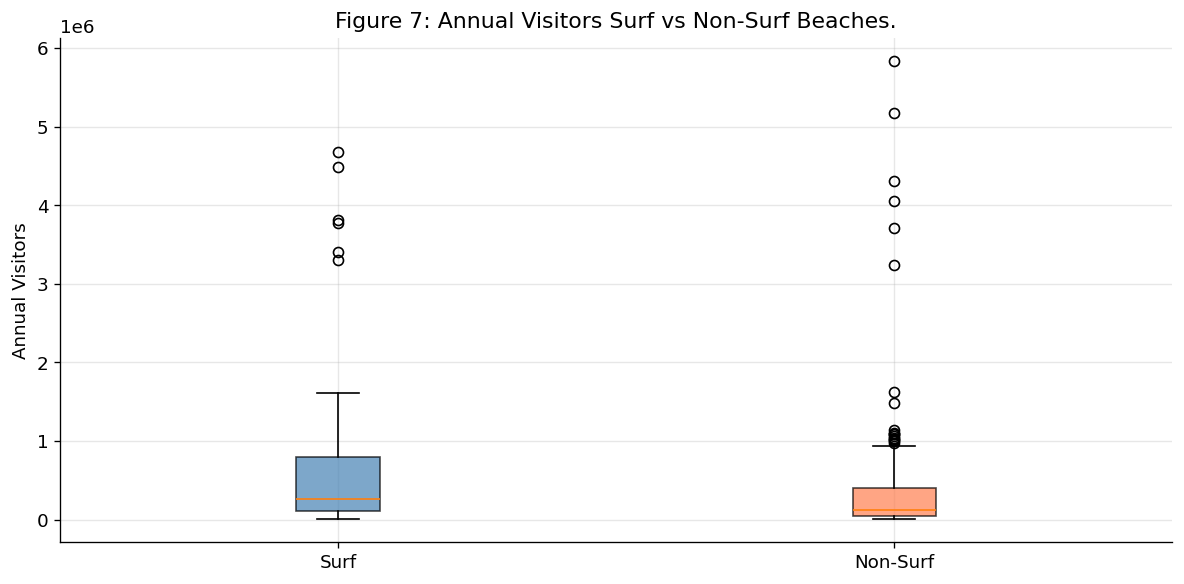

In [43]:
# Side-by-side boxplot to visualise the two groups.
fig, ax = plt.subplots(figsize=(10 , 5 ))
bp = ax.boxplot([surf, non_surf], tick_labels=['Surf', 'Non-Surf'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
for box in bp['boxes']:
    box.set_alpha(0.7)

ax.set_ylabel('Annual Visitors')
ax.set_title('Figure 7: Annual Visitors Surf vs Non-Surf Beaches.')
plt.tight_layout()
plt.show()

### 2.4 Subset Analysis

**Question:** Among NSW beaches, do patrolled beaches have higher facilities ratings
than unpatrolled ones?

**Justification:** NSW is the largest state group (113 beaches), providing sufficient
data for meaningful analysis. Patrol status is a key safety indicator, and understanding
whether patrolled beaches also tend to have better facilities is relevant for
infrastructure and tourism planning.

In [44]:
# Filter to NSW only.
df_nsw = df_main[df_main['State'] == 'NSW'].copy()
print(f'NSW subset shape: {df_nsw.shape}')
print(f'Patrolled breakdown:\n{df_nsw["Patrolled"].value_counts()}')

NSW subset shape: (112, 29)
Patrolled breakdown:
Patrolled
Yes    63
No     49
Name: count, dtype: int64


In [45]:
# Facilities_Rating grouped by Patrolled status.

nsw_facilities = df_nsw.groupby('Patrolled')['Facilities_Rating'].agg(['mean', 'median', 'std', 'count'])
print(nsw_facilities.to_string())

               mean  median       std  count
Patrolled                                   
No         2.979592     3.0  0.594762     49
Yes        3.920635     4.0  0.547769     63


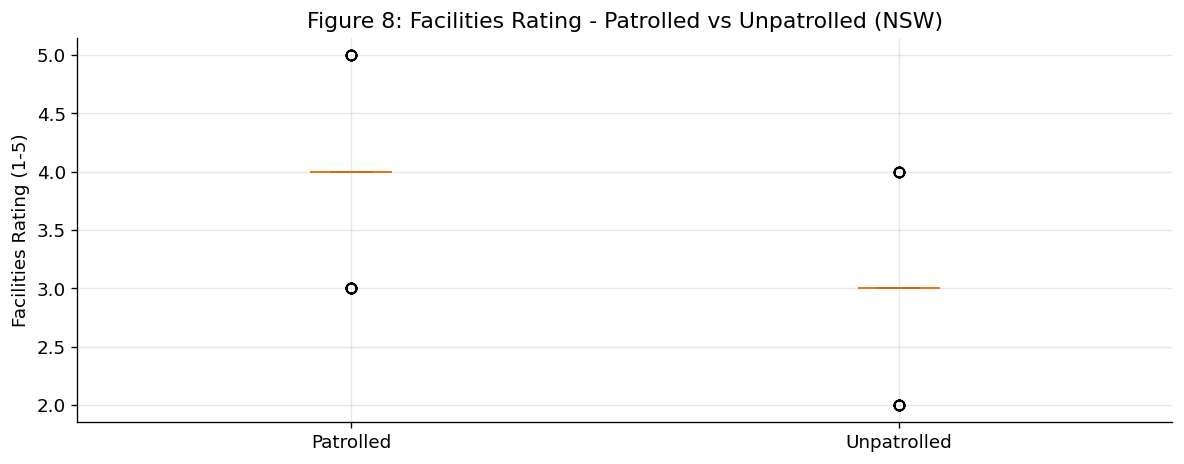

In [46]:
# Grouped boxplot, Facilities Rating by Patrol status in NSW.
patrolled = df_nsw[df_nsw['Patrolled'] == 'Yes']['Facilities_Rating']
unpatrolled = df_nsw[df_nsw['Patrolled'] == 'No']['Facilities_Rating']

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot([patrolled, unpatrolled], tick_labels=['Patrolled', 'Unpatrolled'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
for box in bp['boxes']:
    box.set_alpha(0.7)

ax.set_ylabel('Facilities Rating (1-5)')
ax.set_title('Figure 8: Facilities Rating - Patrolled vs Unpatrolled (NSW)')
plt.tight_layout()
plt.show()

---
<span style="color: #c1382e;">THE END.</span>